## Python Libraries for Data Analytics & Data Science

- **NumPy**: A fundamental library for numerical computing in Python. It enables fast mathematical and statistical operations using efficient array structures and forms the foundation for many features in pandas.

- **Matplotlib**: A powerful visualization library used to create graphs, charts, and plots for data analysis.

- **Seaborn**: A modern data visualization library built on top of Matplotlib, providing more advanced and aesthetically pleasing statistical graphics.

- **Pandas**: A core data analysis library designed for handling structured data. It provides tools for data manipulation, cleaning, and analysis, making it essential for data science workflows.

- **Scikit-learn**: A widely used machine learning library in Python that offers simple and efficient tools for data modeling, classification, regression, and evaluation.



# Project 2: Data Analysis of the Price of Gold from 1833-2026

## Name: Divith
## Course: DS220  


## Problem Space
Gold has historically been a key financial asset used for investment, hedging against inflation, and economic stability. Understanding long term gold price trends helps investors, economists, and policymakers make informed decisions.

This project analyzes nearly 200 years of monthly gold price data to uncover patterns, trends, and insights about how gold prices have evolved over time.


## Dataset Description
The dataset contains monthly gold prices from January 1833 to February 2026. Each row represents a specific month and the corresponding gold price in USD per troy ounce.

### Columns:
- **Date**: The time period (YYYY-MM format)
- **Price**: Gold price in USD per ounce

This dataset is well-suited for time-series analysis, allowing us to explore long-term trends, volatility, and patterns in gold pricing.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("gold_advanced_features.csv")
df.head()

,date,price,year,month,quarter,month_sin,month_cos,lag_1,lag_2,lag_3,...,roll_std_6,momentum_1,momentum_3,pct_change_1,pct_change_3,ewm_3,ewm_6,price_to_roll3,price_to_roll12,volatility_3
0,1834-01-01,18.93,1834,1,1,0.500000,8.660254e-01,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0
1,1834-02-01,18.93,1834,2,1,0.866025,5.000000e-01,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0
2,1834-03-01,18.93,1834,3,1,1.000000,6.123234e-17,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0
3,1834-04-01,18.93,1834,4,2,0.866025,-5.000000e-01,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0
4,1834-05-01,18.93,1834,5,2,0.500000,-8.660254e-01,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0


The dataset is loaded into a pandas DataFrame. The preview shows the structure of the data, including the Date and Price columns.

In [2]:
df["Date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

df.head()

,date,price,year,month,quarter,month_sin,month_cos,lag_1,lag_2,lag_3,...,momentum_1,momentum_3,pct_change_1,pct_change_3,ewm_3,ewm_6,price_to_roll3,price_to_roll12,volatility_3,Date
0,1834-01-01,18.93,1834,1,1,0.500000,8.660254e-01,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0,1834-01-01
1,1834-02-01,18.93,1834,2,1,0.866025,5.000000e-01,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0,1834-02-01
2,1834-03-01,18.93,1834,3,1,1.000000,6.123234e-17,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0,1834-03-01
3,1834-04-01,18.93,1834,4,2,0.866025,-5.000000e-01,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0,1834-04-01
4,1834-05-01,18.93,1834,5,2,0.500000,-8.660254e-01,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0,1834-05-01


In [3]:
df = df.drop(columns=["date"])
df = df.rename(columns={"Date": "date"})

The Date column is converted into datetime format and the dataset is sorted chronologically to prepare it for time-series analysis.

##  Questions to Address

1. How has gold price changed over time?
2. Which periods saw the highest growth in gold prices?
3. What are the average gold prices by decade?
4. How volatile are gold prices over time?
5. Are there noticeable trends or cycles in gold prices?
6. What are the highest and lowest price periods?


##  Exploratory Data Analysis

Before performing detailed analysis, we examine the structure and summary statistics of the dataset to understand its properties and identify any potential issues such as missing values or anomalies.

In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2306 entries, 0 to 2305
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   price            2306 non-null   float64       
 1   year             2306 non-null   int64         
 2   month            2306 non-null   int64         
 3   quarter          2306 non-null   int64         
 4   month_sin        2306 non-null   float64       
 5   month_cos        2306 non-null   float64       
 6   lag_1            2306 non-null   float64       
 7   lag_2            2306 non-null   float64       
 8   lag_3            2306 non-null   float64       
 9   lag_6            2306 non-null   float64       
 10  lag_12           2306 non-null   float64       
 11  roll_mean_3      2306 non-null   float64       
 12  roll_mean_6      2306 non-null   float64       
 13  roll_mean_12     2306 non-null   float64       
 14  roll_std_3       2306 non-null   float64       
 15

price              0
year               0
month              0
quarter            0
month_sin          0
month_cos          0
lag_1              0
lag_2              0
lag_3              0
lag_6              0
lag_12             0
roll_mean_3        0
roll_mean_6        0
roll_mean_12       0
roll_std_3         0
roll_std_6         0
momentum_1         0
momentum_3         0
pct_change_1       0
pct_change_3       0
ewm_3              0
ewm_6              0
price_to_roll3     0
price_to_roll12    0
volatility_3       0
date               0
dtype: int64

##  Visualizations

Visualizations help us better understand trends and patterns in the data. The following graphs illustrate how gold prices have evolved over time and highlight important patterns such as growth and volatility.


##  Data Analysis and Answers

In this section, we analyze the dataset to answer the questions defined earlier using pandas operations and statistical summaries.


###  Q1 - Trend over time

<Axes: xlabel='date'>

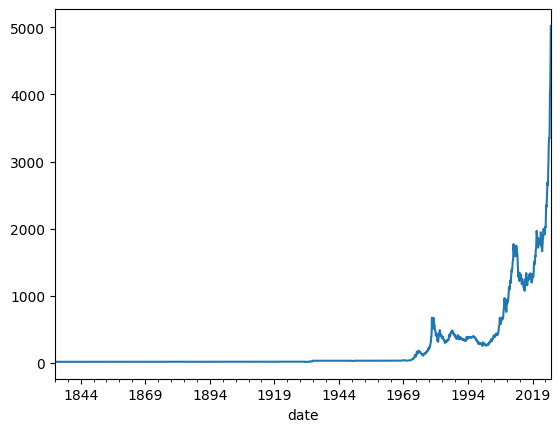

In [5]:
df.set_index("date")["price"].plot()

Gold prices show a strong long-term upward trend, especially in recent decades.

###  Q2 - Which periods saw the highest growth?

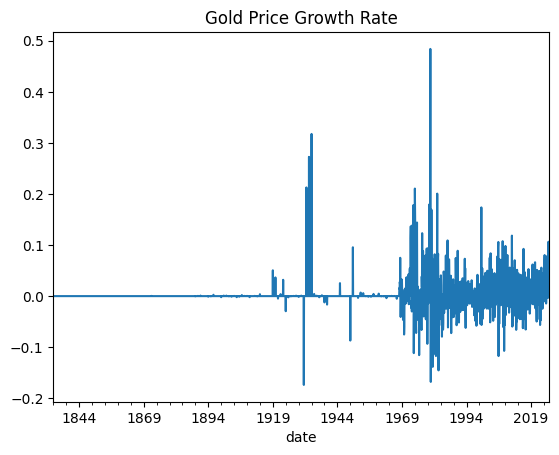

In [6]:
df["price_change"] = df["price"].pct_change()
df.set_index("date")["price_change"].plot()
plt.title("Gold Price Growth Rate")
plt.show()

The growth rate plot shows that gold prices experienced minimal changes in earlier periods, remaining largely stable. However, sharp spikes in growth appear in the mid-20th century and especially in recent decades, indicating periods of rapid price increases. These spikes suggest that the highest growth in gold prices occurred during times of economic instability and increased demand for gold as a safe-haven asset.

###  Q3 - Average price by decade

In [7]:
df["year"] = df["date"].dt.year
df["decade"] = (df["year"] // 10) * 10

df.groupby("decade")["price"].mean()

decade
1830      18.930000
1840      18.930000
1850      18.930000
1860      18.930000
1870      18.938000
1880      18.939000
1890      18.957000
1900      18.949000
1910      19.059000
1920      20.713000
1930      29.319000
1940      33.978000
1950      34.909000
1960      36.114833
1970     132.494833
1980     417.697667
1990     350.904917
2000     522.328508
2010    1346.936842
2020    2263.257297
Name: price, dtype: float64

The average gold price remains relatively constant and low from the 1830s to the early 1900s, indicating long-term price stability. A noticeable increase begins in the mid-20th century, with a dramatic rise from the 1970s onward. The most significant growth occurs in the 2000s and 2010s, where average prices increase sharply, reflecting strong long-term appreciation of gold.

###  Q4 - How volatile are prices?

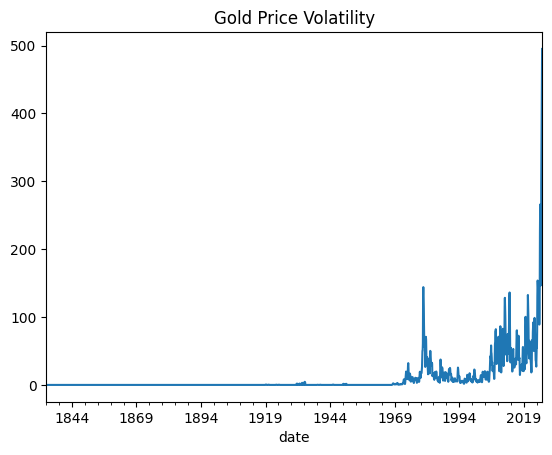

In [8]:
df.set_index("date")["roll_std_6"].plot()
plt.title("Gold Price Volatility")
plt.show()

Gold price volatility remains extremely low during the early historical period, indicating stable pricing. From the 1970s onward, volatility increases significantly, with larger fluctuations in recent decades. This suggests that gold markets have become more dynamic and sensitive to global economic conditions over time.

###  Q5 - Trends or cycles?

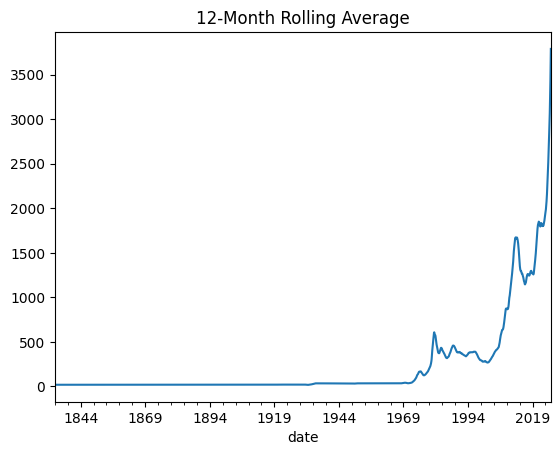

In [9]:
df.set_index("date")["roll_mean_12"].plot()
plt.title("12-Month Rolling Average")
plt.show()

The rolling average highlights a clear long-term upward trend in gold prices. While short-term fluctuations and minor cycles are visible, the overall direction remains consistently upward. This indicates that gold has experienced sustained long-term growth rather than repeating cyclical patterns.

###  Q6 - Highest and Lowest Periods

In [10]:
highest = df.loc[df["price"].idxmax()]
lowest = df.loc[df["price"].idxmin()]

print("Highest Price:")
print(highest["date"].strftime("%Y-%m"), highest["price"])

print("\nLowest Price:")
print(lowest["date"].strftime("%Y-%m"), lowest["price"])

Highest Price:
2026-02 5019.97

Lowest Price:
1931-01 17.06


Gold prices reached their highest level in February 2026 at approximately $5019.97, marking the culmination of a long-term upward trend. The lowest price occurred in January 1931 at around $17.06, during a period of relative price stability. This contrast illustrates the dramatic appreciation of gold over time and its increasing role as a store of value in modern financial markets.

##  Key Insights

- Gold prices show a strong upward trend over the long term, especially after the 20th century.
- Significant price increases occur during periods of economic uncertainty.
- Volatility in gold prices has increased in more recent decades.
- Gold remains a reliable long-term store of value despite short-term fluctuations.


The dataset contains 2,306 entries with no missing values, indicating it is clean and ready for analysis. The presence of multiple engineered features such as rolling averages, lag values, and momentum indicators provides deeper insights into gold price behavior over time.

##  Conclusion

This analysis demonstrates that gold prices have experienced substantial growth over nearly two centuries. While short-term fluctuations exist, the long-term trend shows consistent appreciation in value.
The findings highlight gold’s role as a stable financial asset and its importance in global economic systems.
